In [52]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
import os
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns

In [53]:
data=pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\SAK\Mines Datasheet-Tabelle 1.csv", on_bad_lines="skip")
data

,,,,,SL No.;State/UT Name;District Name;Mine Name;Coal/ Lignite Production (MT) (2019-2020);Coal Mine Owner Name;Coal Mine Owner Full Name;Coal/Lignite;Govt Owned/Private;Type of Mine (OC/UG/Mixed);Latitude ;Longitude ;Source;Accuracy (exact vs approximate);
1;West Bengal;Paschim Bardhaman;Ningah Colliery ;0,01;ECL;Eastern Coalfields Limited;Coal;G;UG;23,6743;87,0333;Google Maps: https://www.google.com/maps/place/NINGAH+COLLIERY+PM+OFFICE/@23.6742772,87.0331657,21z/data=!4m12!1m6!3m5!1s0x39f719bb00000001:0x...
2;West Bengal;Paschim Bardhaman;Jhanjhara Project Colly;3,5;ECL;Eastern Coalfields Limited;Coal;G;UG;23,668;87,2963;Google Maps: https://www.google.ca/maps/place/1%262+Incline+jhanjra+project+Eastern+Coal+Field+Limited/@23.6675767,87.2936117,17z/data=!4m12!1m6!3m5!1s0x0:0xae7d2a00ed82263...
"3;West Bengal;Paschim Bardhaman;""MAOHUSUDANPUR 7 PIT &",NaN,NaN,NaN,NaN,NaN
"INCLINE"";0",04;ECL;Eastern Coalfields Limited;Coal;G;UG;23,6338;87,2037;Google Maps: https://www.google.com/maps/place/Madhusudanpur+Colliery+Agent+Office/@23.6337717,87.2037697,20z/data=!4m6!3m5!1s0x39f7135d095c14b5:0xb3f15...
6;West Bengal;Paschim Bardhaman;Jambad UG;0,16;ECL;Eastern Coalfields Limited;Coal;G;UG;23,6517;87,1734;Google Maps: https://www.google.com/maps/place/Jambad+ug+Coolliery/@23.6517347,87.1733076,21z/data=!4m12!1m6!3m5!1s0x39f71549f1303833:0x...
...,...,...,...,...,...
455;Telangana ;Peddapalli;GDK 1&3 INC;0,214798;SCCL;The Singareni Collieries Company Limited;Coal;SG;UG;18,0452;79,3025;Environmental clearance https://scclmines.com/env/docs/MARQUEE.pdf;Exact;,NaN,NaN
456;Telangana ;Peddapalli;GDK 2&2A INC;0,283656;SCCL;The Singareni Collieries Company Limited;Coal;SG;UG;18,4221;79,3111;Brief Summary SCCL: http://environmentclearance.nic.in/writereaddata/Online/TOR/05_May_2019_114123650H6A5CJ3PAnnex-3.pdf;Exact;,NaN,NaN
457;Telangana ;Peddapalli;GDK 5 INC;0,018202;SCCL;The Singareni Collieries Company Limited;Coal;SG;UG;18,4545;79,3546;Brief Summary SCCL: http://environmentclearance.nic.in/writereaddata/Online/TOR/05_May_2019_114123650H6A5CJ3PAnnex-3.pdf;Exact;,NaN,NaN
458;Telangana ;Peddapalli;GDK 11 INC;0,804029;SCCL;The Singareni Collieries Company Limited;Coal;SG;UG;18,4161;79,3258;Environmental clearance https://scclmines.com/env/docs/ECS/200071.pdf;Exact;,NaN,NaN


In [54]:
data=pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\SAK\Mines Datasheet-Tabelle 1.csv",on_bad_lines="warn")
data

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16260\213389986.py:1: ParserWarning: Skipping line 6: expected 6 fields, saw 8
Skipping line 7: expected 6 fields, saw 8
Skipping line 9: expected 6 fields, saw 8
Skipping line 18: expected 6 fields, saw 7
Skipping line 20: expected 6 fields, saw 8
Skipping line 22: expected 6 fields, saw 8
Skipping line 25: expected 6 fields, saw 9
Skipping line 39: expected 6 fields, saw 8
Skipping line 42: expected 6 fields, saw 10
Skipping line 43: expected 6 fields, saw 8
Skipping line 44: expected 6 fields, saw 9
Skipping line 45: expected 6 fields, saw 9
Skipping line 49: expected 6 fields, saw 8
Skipping line 53: expected 6 fields, saw 8
Skipping line 55: expected 6 fields, saw 10
Skipping line 62: expected 6 fields, saw 8
Skipping line 69: expected 6 fields, saw 8
Skipping line 71: expected 6 fields, saw 10
Skipping line 72: expected 6 fields, saw 7
Skipping line 73: expected 6 fields, saw 8
Skipping line 75: expected 6 fields, saw 7
Skipping line 7

,,,,,SL No.;State/UT Name;District Name;Mine Name;Coal/ Lignite Production (MT) (2019-2020);Coal Mine Owner Name;Coal Mine Owner Full Name;Coal/Lignite;Govt Owned/Private;Type of Mine (OC/UG/Mixed);Latitude ;Longitude ;Source;Accuracy (exact vs approximate);
1;West Bengal;Paschim Bardhaman;Ningah Colliery ;0,01;ECL;Eastern Coalfields Limited;Coal;G;UG;23,6743;87,0333;Google Maps: https://www.google.com/maps/place/NINGAH+COLLIERY+PM+OFFICE/@23.6742772,87.0331657,21z/data=!4m12!1m6!3m5!1s0x39f719bb00000001:0x...
2;West Bengal;Paschim Bardhaman;Jhanjhara Project Colly;3,5;ECL;Eastern Coalfields Limited;Coal;G;UG;23,668;87,2963;Google Maps: https://www.google.ca/maps/place/1%262+Incline+jhanjra+project+Eastern+Coal+Field+Limited/@23.6675767,87.2936117,17z/data=!4m12!1m6!3m5!1s0x0:0xae7d2a00ed82263...
"3;West Bengal;Paschim Bardhaman;""MAOHUSUDANPUR 7 PIT &",NaN,NaN,NaN,NaN,NaN
"INCLINE"";0",04;ECL;Eastern Coalfields Limited;Coal;G;UG;23,6338;87,2037;Google Maps: https://www.google.com/maps/place/Madhusudanpur+Colliery+Agent+Office/@23.6337717,87.2037697,20z/data=!4m6!3m5!1s0x39f7135d095c14b5:0xb3f15...
6;West Bengal;Paschim Bardhaman;Jambad UG;0,16;ECL;Eastern Coalfields Limited;Coal;G;UG;23,6517;87,1734;Google Maps: https://www.google.com/maps/place/Jambad+ug+Coolliery/@23.6517347,87.1733076,21z/data=!4m12!1m6!3m5!1s0x39f71549f1303833:0x...
...,...,...,...,...,...
455;Telangana ;Peddapalli;GDK 1&3 INC;0,214798;SCCL;The Singareni Collieries Company Limited;Coal;SG;UG;18,0452;79,3025;Environmental clearance https://scclmines.com/env/docs/MARQUEE.pdf;Exact;,NaN,NaN
456;Telangana ;Peddapalli;GDK 2&2A INC;0,283656;SCCL;The Singareni Collieries Company Limited;Coal;SG;UG;18,4221;79,3111;Brief Summary SCCL: http://environmentclearance.nic.in/writereaddata/Online/TOR/05_May_2019_114123650H6A5CJ3PAnnex-3.pdf;Exact;,NaN,NaN
457;Telangana ;Peddapalli;GDK 5 INC;0,018202;SCCL;The Singareni Collieries Company Limited;Coal;SG;UG;18,4545;79,3546;Brief Summary SCCL: http://environmentclearance.nic.in/writereaddata/Online/TOR/05_May_2019_114123650H6A5CJ3PAnnex-3.pdf;Exact;,NaN,NaN
458;Telangana ;Peddapalli;GDK 11 INC;0,804029;SCCL;The Singareni Collieries Company Limited;Coal;SG;UG;18,4161;79,3258;Environmental clearance https://scclmines.com/env/docs/ECS/200071.pdf;Exact;,NaN,NaN


In [55]:
data.shape

(376, 1)

In [56]:
data = pd.read_csv(
    r"C:\Users\Lenovo\OneDrive\Desktop\SAK\Mines Datasheet-Tabelle 1.csv",
    sep=';',
    engine='python',
    on_bad_lines='skip'
)
data

,SL No.,State/UT Name,District Name,Mine Name,Coal/ Lignite Production (MT) (2019-2020),Coal Mine Owner Name,Coal Mine Owner Full Name,Coal/Lignite,Govt Owned/Private,Type of Mine (OC/UG/Mixed),Latitude,Longitude,Source,Accuracy (exact vs approximate),Unnamed: 14
0,1,West Bengal,Paschim Bardhaman,Ningah Colliery,"0,01",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6743","87,0333",Google Maps: https://www.google.com/maps/place...,Exact,NaN
1,2,West Bengal,Paschim Bardhaman,Jhanjhara Project Colly,"3,5",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,668","87,2963",Google Maps: https://www.google.ca/maps/place/...,Exact,NaN
2,3,West Bengal,Paschim Bardhaman,MAOHUSUDANPUR 7 PIT &\nINCLINE,"0,04",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6338","87,2037",Google Maps: https://www.google.com/maps/place...,Approximate: Madhusudanpur Colliery Agent Office,NaN
3,4,West Bengal,Paschim Bardhaman,PARASCOLE(EAST),"0,1",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6377","87,1951",Google Maps: https://www.google.com/maps/place...,Approximate: center coordinates of eastern Par...,NaN
4,5,West Bengal,Paschim Bardhaman,PARASCOLE(WEST),"0,07",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6405","87,1855",Google Maps: https://www.google.com/maps/place...,Approximate: center coordinates of western Par...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,455,Telangana,Peddapalli,GDK 1&3 INC,"0,214798",SCCL,The Singareni Collieries Company Limited,Coal,SG,UG,"18,0452","79,3025",Environmental clearance https://scclmines.com/...,Exact,NaN
455,456,Telangana,Peddapalli,GDK 2&2A INC,"0,283656",SCCL,The Singareni Collieries Company Limited,Coal,SG,UG,"18,4221","79,3111",Brief Summary SCCL: http://environmentclearanc...,Exact,NaN
456,457,Telangana,Peddapalli,GDK 5 INC,"0,018202",SCCL,The Singareni Collieries Company Limited,Coal,SG,UG,"18,4545","79,3546",Brief Summary SCCL: http://environmentclearanc...,Exact,NaN
457,458,Telangana,Peddapalli,GDK 11 INC,"0,804029",SCCL,The Singareni Collieries Company Limited,Coal,SG,UG,"18,4161","79,3258",Environmental clearance https://scclmines.com/...,Exact,NaN


<Axes: xlabel='Coal/Lignite', ylabel='count'>

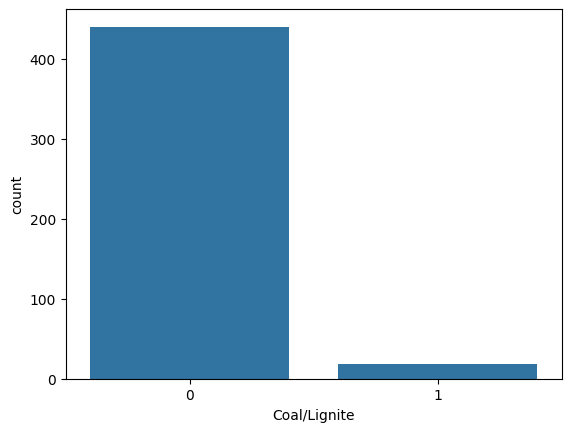

In [104]:
sns.countplot(x='Coal/Lignite', data = data)

In [57]:
data = data.drop(columns=["Unnamed: 14"], errors="ignore")

In [58]:
data['Coal/Lignite'].unique()

array(['Coal', 'Lignite'], dtype=object)

In [59]:
data.shape

(459, 14)

In [60]:
data.describe

<bound method NDFrame.describe of      SL No. State/UT Name      District Name                       Mine Name  \
0         1   West Bengal  Paschim Bardhaman                Ningah Colliery    
1         2   West Bengal  Paschim Bardhaman         Jhanjhara Project Colly   
2         3   West Bengal  Paschim Bardhaman  MAOHUSUDANPUR 7 PIT &\nINCLINE   
3         4   West Bengal  Paschim Bardhaman                PARASCOLE(EAST)    
4         5   West Bengal  Paschim Bardhaman                PARASCOLE(WEST)    
..      ...           ...                ...                             ...   
454     455    Telangana          Peddapalli                     GDK 1&3 INC   
455     456    Telangana          Peddapalli                    GDK 2&2A INC   
456     457    Telangana          Peddapalli                       GDK 5 INC   
457     458    Telangana          Peddapalli                      GDK 11 INC   
458     459    Telangana          Peddapalli                      GDK 10 INC   

    C

In [61]:
data.info

<bound method DataFrame.info of      SL No. State/UT Name      District Name                       Mine Name  \
0         1   West Bengal  Paschim Bardhaman                Ningah Colliery    
1         2   West Bengal  Paschim Bardhaman         Jhanjhara Project Colly   
2         3   West Bengal  Paschim Bardhaman  MAOHUSUDANPUR 7 PIT &\nINCLINE   
3         4   West Bengal  Paschim Bardhaman                PARASCOLE(EAST)    
4         5   West Bengal  Paschim Bardhaman                PARASCOLE(WEST)    
..      ...           ...                ...                             ...   
454     455    Telangana          Peddapalli                     GDK 1&3 INC   
455     456    Telangana          Peddapalli                    GDK 2&2A INC   
456     457    Telangana          Peddapalli                       GDK 5 INC   
457     458    Telangana          Peddapalli                      GDK 11 INC   
458     459    Telangana          Peddapalli                      GDK 10 INC   

    Coa

In [62]:
data.head

<bound method NDFrame.head of      SL No. State/UT Name      District Name                       Mine Name  \
0         1   West Bengal  Paschim Bardhaman                Ningah Colliery    
1         2   West Bengal  Paschim Bardhaman         Jhanjhara Project Colly   
2         3   West Bengal  Paschim Bardhaman  MAOHUSUDANPUR 7 PIT &\nINCLINE   
3         4   West Bengal  Paschim Bardhaman                PARASCOLE(EAST)    
4         5   West Bengal  Paschim Bardhaman                PARASCOLE(WEST)    
..      ...           ...                ...                             ...   
454     455    Telangana          Peddapalli                     GDK 1&3 INC   
455     456    Telangana          Peddapalli                    GDK 2&2A INC   
456     457    Telangana          Peddapalli                       GDK 5 INC   
457     458    Telangana          Peddapalli                      GDK 11 INC   
458     459    Telangana          Peddapalli                      GDK 10 INC   

    Coal/

In [63]:
data.tail

<bound method NDFrame.tail of      SL No. State/UT Name      District Name                       Mine Name  \
0         1   West Bengal  Paschim Bardhaman                Ningah Colliery    
1         2   West Bengal  Paschim Bardhaman         Jhanjhara Project Colly   
2         3   West Bengal  Paschim Bardhaman  MAOHUSUDANPUR 7 PIT &\nINCLINE   
3         4   West Bengal  Paschim Bardhaman                PARASCOLE(EAST)    
4         5   West Bengal  Paschim Bardhaman                PARASCOLE(WEST)    
..      ...           ...                ...                             ...   
454     455    Telangana          Peddapalli                     GDK 1&3 INC   
455     456    Telangana          Peddapalli                    GDK 2&2A INC   
456     457    Telangana          Peddapalli                       GDK 5 INC   
457     458    Telangana          Peddapalli                      GDK 11 INC   
458     459    Telangana          Peddapalli                      GDK 10 INC   

    Coal/

In [64]:
data.isnull

<bound method DataFrame.isnull of      SL No. State/UT Name      District Name                       Mine Name  \
0         1   West Bengal  Paschim Bardhaman                Ningah Colliery    
1         2   West Bengal  Paschim Bardhaman         Jhanjhara Project Colly   
2         3   West Bengal  Paschim Bardhaman  MAOHUSUDANPUR 7 PIT &\nINCLINE   
3         4   West Bengal  Paschim Bardhaman                PARASCOLE(EAST)    
4         5   West Bengal  Paschim Bardhaman                PARASCOLE(WEST)    
..      ...           ...                ...                             ...   
454     455    Telangana          Peddapalli                     GDK 1&3 INC   
455     456    Telangana          Peddapalli                    GDK 2&2A INC   
456     457    Telangana          Peddapalli                       GDK 5 INC   
457     458    Telangana          Peddapalli                      GDK 11 INC   
458     459    Telangana          Peddapalli                      GDK 10 INC   

    C

In [65]:
data.fillna(200)

,SL No.,State/UT Name,District Name,Mine Name,Coal/ Lignite Production (MT) (2019-2020),Coal Mine Owner Name,Coal Mine Owner Full Name,Coal/Lignite,Govt Owned/Private,Type of Mine (OC/UG/Mixed),Latitude,Longitude,Source,Accuracy (exact vs approximate)
0,1,West Bengal,Paschim Bardhaman,Ningah Colliery,"0,01",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6743","87,0333",Google Maps: https://www.google.com/maps/place...,Exact
1,2,West Bengal,Paschim Bardhaman,Jhanjhara Project Colly,"3,5",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,668","87,2963",Google Maps: https://www.google.ca/maps/place/...,Exact
2,3,West Bengal,Paschim Bardhaman,MAOHUSUDANPUR 7 PIT &\nINCLINE,"0,04",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6338","87,2037",Google Maps: https://www.google.com/maps/place...,Approximate: Madhusudanpur Colliery Agent Office
3,4,West Bengal,Paschim Bardhaman,PARASCOLE(EAST),"0,1",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6377","87,1951",Google Maps: https://www.google.com/maps/place...,Approximate: center coordinates of eastern Par...
4,5,West Bengal,Paschim Bardhaman,PARASCOLE(WEST),"0,07",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6405","87,1855",Google Maps: https://www.google.com/maps/place...,Approximate: center coordinates of western Par...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,455,Telangana,Peddapalli,GDK 1&3 INC,"0,214798",SCCL,The Singareni Collieries Company Limited,Coal,SG,UG,"18,0452","79,3025",Environmental clearance https://scclmines.com/...,Exact
455,456,Telangana,Peddapalli,GDK 2&2A INC,"0,283656",SCCL,The Singareni Collieries Company Limited,Coal,SG,UG,"18,4221","79,3111",Brief Summary SCCL: http://environmentclearanc...,Exact
456,457,Telangana,Peddapalli,GDK 5 INC,"0,018202",SCCL,The Singareni Collieries Company Limited,Coal,SG,UG,"18,4545","79,3546",Brief Summary SCCL: http://environmentclearanc...,Exact
457,458,Telangana,Peddapalli,GDK 11 INC,"0,804029",SCCL,The Singareni Collieries Company Limited,Coal,SG,UG,"18,4161","79,3258",Environmental clearance https://scclmines.com/...,Exact


In [66]:
data.isnull().sum()

SL No.                                        0
State/UT Name                                 0
District Name                                 0
Mine Name                                     0
Coal/ Lignite Production (MT) (2019-2020)     0
Coal Mine Owner Name                          0
Coal Mine Owner Full Name                    11
Coal/Lignite                                  0
Govt Owned/Private                            0
Type of Mine (OC/UG/Mixed)                    0
Latitude                                      0
Longitude                                     0
Source                                        0
Accuracy (exact vs approximate)               0
dtype: int64

In [67]:
data.shape

(459, 14)

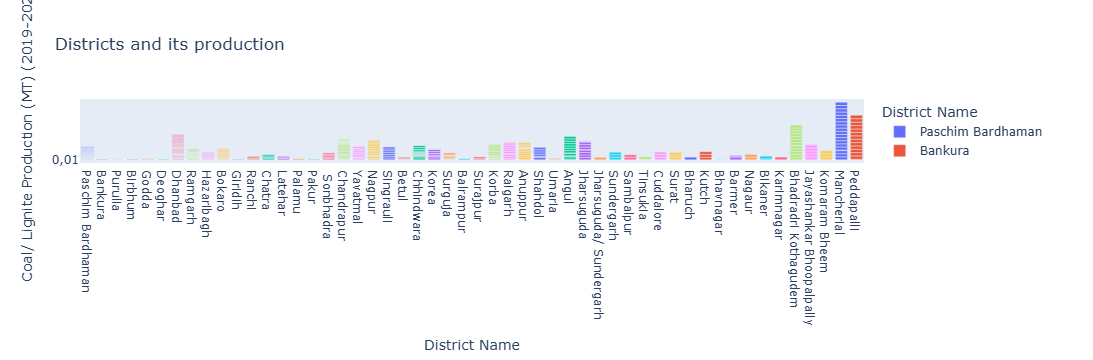

In [68]:
fig=px.bar(data,x="District Name",y="Coal/ Lignite Production (MT) (2019-2020)",color="District Name",title="Districts and its production")
fig.show()

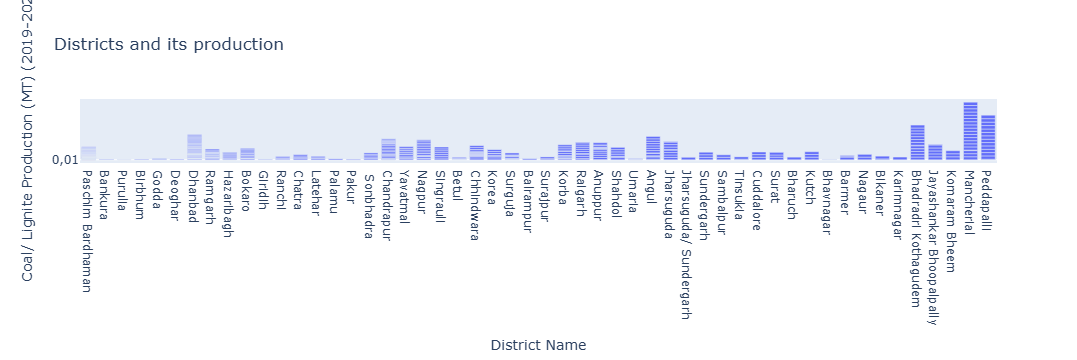

In [69]:
fig=px.bar(data,x="District Name",y="Coal/ Lignite Production (MT) (2019-2020)",title="Districts and its production")
fig.show()

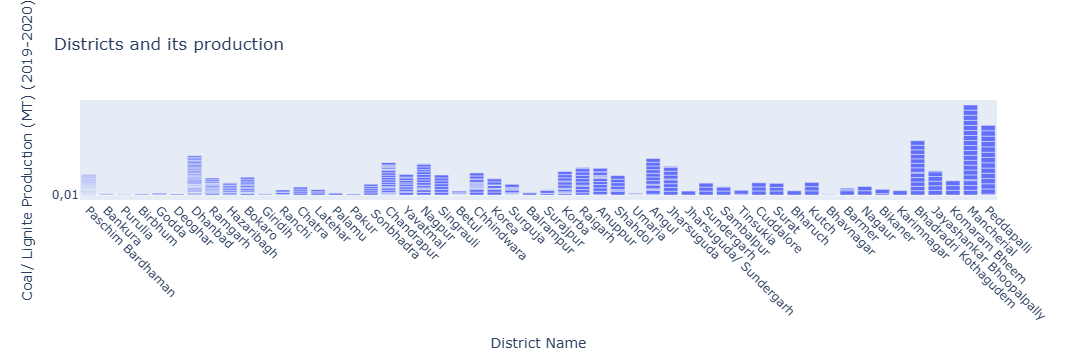

In [70]:
fig = px.bar(data,x="District Name",y="Coal/ Lignite Production (MT) (2019-2020)",title="Districts and its production")
fig.update_layout(xaxis_tickangle=45)  
fig.show()

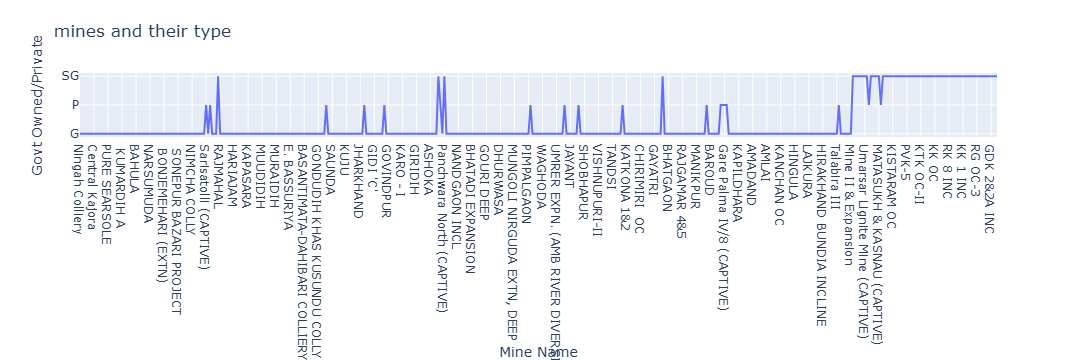

In [71]:
fig1=px.line(data,x="Mine Name",y="Govt Owned/Private",title="mines and their type")
fig1.show()

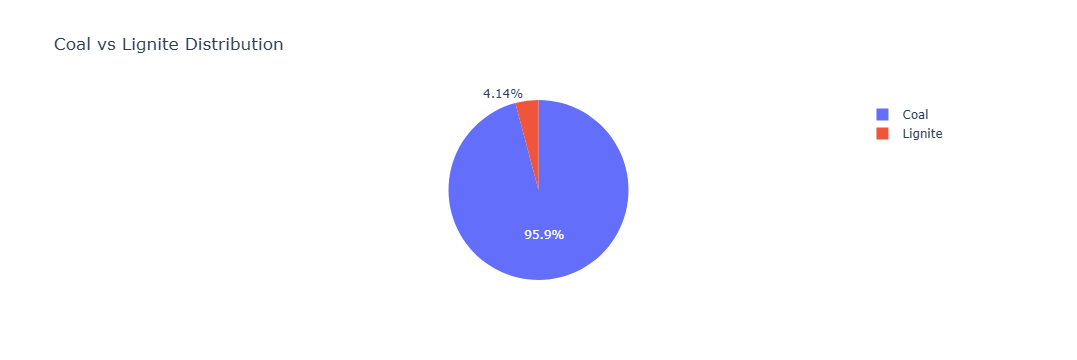

In [72]:
fig3= px.pie(data,names="Coal/Lignite", title="Coal vs Lignite Distribution")
fig3.show()

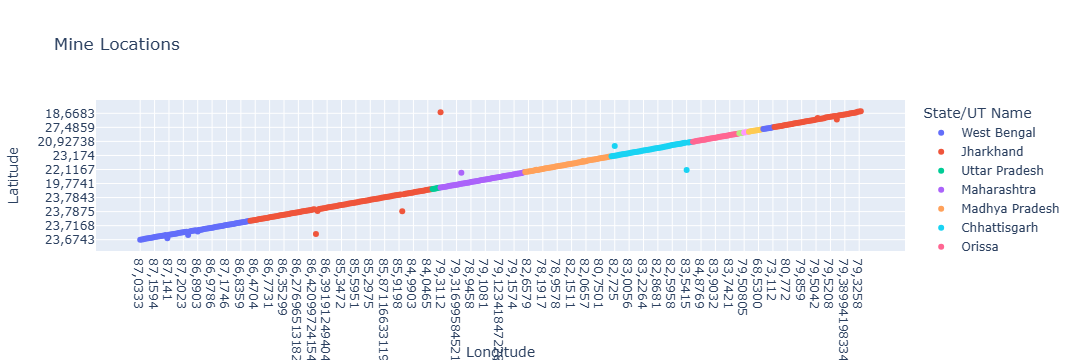

In [73]:
fig4= px.scatter(data,x="Longitude ", y="Latitude ", color="State/UT Name",title="Mine Locations")
fig4.show()

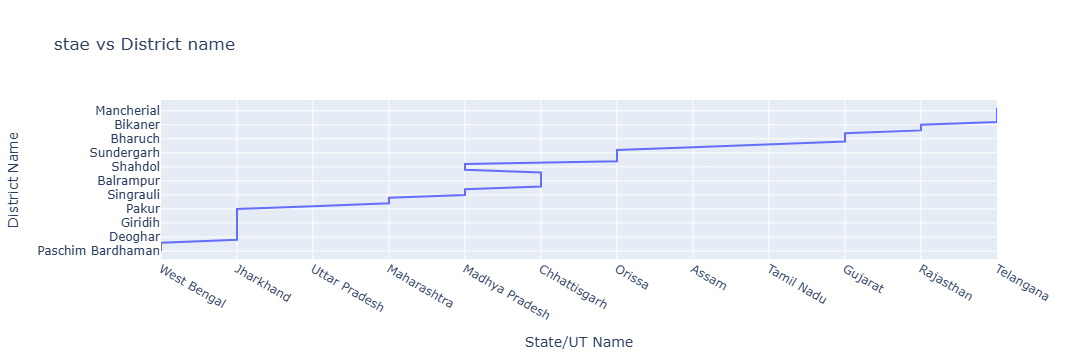

In [74]:
fig5= px.line(data,x="State/UT Name",y="District Name",title="stae vs District name")
fig5.show()

In [75]:
fig6=px.scatter(data,x="Coal Mine Owner Full Name", y="Mine Name",color="Coal Mine Owner Full Name",size="Coal/ Lignite Production (MT) (2019-2020)",title="mine vs owner")
fog6

TypeError: unsupported operand type(s) for /: 'str' and 'int'

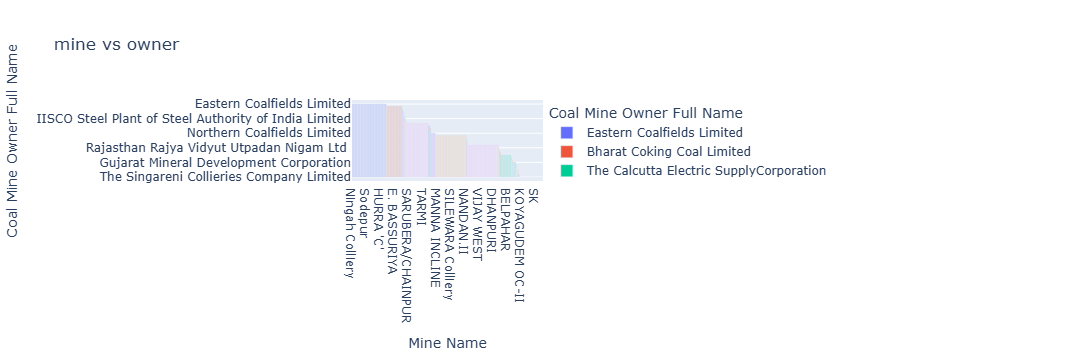

In [76]:
fig7=px.bar(data,x="Mine Name",y="Coal Mine Owner Full Name",color="Coal Mine Owner Full Name",title="mine vs owner")
fig7


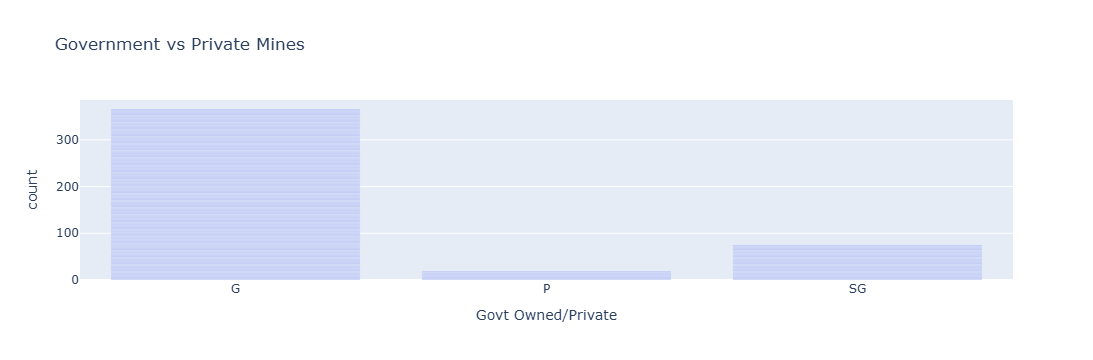

In [77]:
fig8=px.bar(data, x="Govt Owned/Private", title="Government vs Private Mines")
fig8.show()

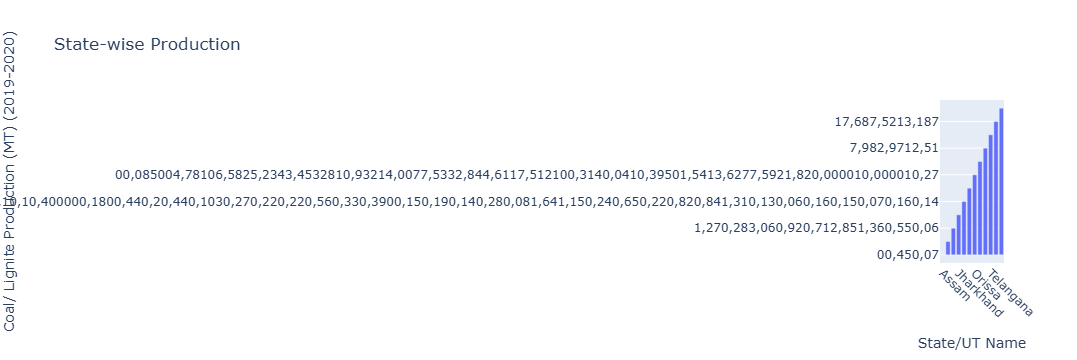

In [78]:
fig9=data.groupby("State/UT Name")["Coal/ Lignite Production (MT) (2019-2020)"].sum().reset_index()
fig10= px.bar(fig9,x="State/UT Name",y="Coal/ Lignite Production (MT) (2019-2020)", title="State-wise Production")
fig10.update_layout(xaxis_tickangle=45)
fig10.show()

In [79]:
data.sort_values(by="Mine Name")

,SL No.,State/UT Name,District Name,Mine Name,Coal/ Lignite Production (MT) (2019-2020),Coal Mine Owner Name,Coal Mine Owner Full Name,Coal/Lignite,Govt Owned/Private,Type of Mine (OC/UG/Mixed),Latitude,Longitude,Source,Accuracy (exact vs approximate)
415,416,Telangana,Bhadradri Kothagudem,21 INC,"0,000972",SCCL,The Singareni Collieries Company Limited,Coal,SG,UG,"17,5949","80,2244",Half-Yearly Compliance Report of Environmental...,Exact
164,165,Jharkhand,Bokaro,A A D OCM,"1,43",CCL,Central Coalfields Limited,Coal,G,OC,"23,7666344835697","85,9855209793535",Google Maps: https://www.google.com/maps/place...,Approximate: Dhori Area GM office
237,238,Maharashtra,Nagpur,ADASA UG TO OC,"0,004",WCL,Western Coalfields Limited,Coal,G,OC,"21,3399","78,9538",Executive Summary EIA & EMP for Public Hearing...,Exact
113,114,Jharkhand,Dhanbad,AGKCC,"0,16",BCCL,Bharat Coking Coal Limited,Coal,G,OC,"23,8098399390537","86,2917913877319",Google Maps: https://www.google.com/maps/searc...,Approximate: coordinates of the Khatras area
163,164,Jharkhand,Bokaro,AKK OCP,"4,45",CCL,Central Coalfields Limited,Coal,G,OC,"23,7905","85,9198",Google Maps: https://www.google.com/maps/place...,Exact
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23,24,West Bengal,Paschim Bardhaman,SANKARPUR,"0,27",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6839","87,2382",Google Maps: https://www.google.com/maps/place...,Exact
20,21,West Bengal,Paschim Bardhaman,SHYAMSUNOERPUR,"0,83",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6483","87,2575",Google Maps: https://www.google.com/maps/place...,Approximate
30,31,West Bengal,Paschim Bardhaman,SIDULI COLLY,"0,09",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6499","87,2093",Google Maps: https://www.google.com/maps/place...,Exact
49,50,West Bengal,Paschim Bardhaman,SONEPUR BAZARI PROJECT,"11,1",ECL,Eastern Coalfields Limited,Coal,G,OC,"23,7011","87,2054",Google Maps: https://www.google.com/maps/place...,Approximate: coordinates of nearby Sonepur Baz...


In [80]:
data.sort_values(by="State/UT Name")

,SL No.,State/UT Name,District Name,Mine Name,Coal/ Lignite Production (MT) (2019-2020),Coal Mine Owner Name,Coal Mine Owner Full Name,Coal/Lignite,Govt Owned/Private,Type of Mine (OC/UG/Mixed),Latitude,Longitude,Source,Accuracy (exact vs approximate)
381,382,Assam,Tinsukia,Tirap,"0,45",NEC,North Eastern Coalfields,Coal,G,OC,"27,2924","95,7904","Tirap OCP Environment Clearance, Form 1: http:...",Exact
380,381,Assam,Tinsukia,Tipong,0,NEC,North Eastern Coalfields,Coal,G,UG,"27,3039","95,8556",Mining Proposal for Introduction of New Mining...,Exact
382,383,Assam,Tinsukia,Tikak,"0,07",NEC,North Eastern Coalfields,Coal,G,OC,"27,2836","95,7334",Google Maps: https://www.google.ca/maps/place/...,Exact
289,290,Chhattisgarh,Surguja,AMGAON,0,SECL,South Eastern Coalfields Limited,Coal,G,OC,"23,1367","82,83",Project Report for Amgaon Opencast Project: ht...,Exact
316,317,Chhattisgarh,Raigarh,JAMPALI,"2,24",SECL,South Eastern Coalfields Limited,Coal,G,OC,"22,2843","83,3025","Environmental Clearance, Jampali OCP: http://e...",Exact
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49,50,West Bengal,Paschim Bardhaman,SONEPUR BAZARI PROJECT,"11,1",ECL,Eastern Coalfields Limited,Coal,G,OC,"23,7011","87,2054",Google Maps: https://www.google.com/maps/place...,Approximate: coordinates of nearby Sonepur Baz...
50,51,West Bengal,Paschim Bardhaman,JAMBAD,"0,59",ECL,Eastern Coalfields Limited,Coal,G,OC,"23,654","87,177",Google Maps: https://www.google.com/maps/place...,Approximate: center coordinate of Jambad colli...
51,52,West Bengal,Paschim Bardhaman,NORTH SEARSOLE,"0,65",ECL,Eastern Coalfields Limited,Coal,G,OC,"23,6626","87,1142",Google Maps: https://www.google.com/maps/place...,Approximate: PIN 713362
45,46,West Bengal,Paschim Bardhaman,DABAR PH III,"1,03",ECL,Eastern Coalfields Limited,Coal,G,OC,"23,7895","86,9173",Google Maps: https://www.google.com/maps/place...,Approximate: Dabor Coal Mines


In [81]:
data.drop(415)

,SL No.,State/UT Name,District Name,Mine Name,Coal/ Lignite Production (MT) (2019-2020),Coal Mine Owner Name,Coal Mine Owner Full Name,Coal/Lignite,Govt Owned/Private,Type of Mine (OC/UG/Mixed),Latitude,Longitude,Source,Accuracy (exact vs approximate)
0,1,West Bengal,Paschim Bardhaman,Ningah Colliery,"0,01",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6743","87,0333",Google Maps: https://www.google.com/maps/place...,Exact
1,2,West Bengal,Paschim Bardhaman,Jhanjhara Project Colly,"3,5",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,668","87,2963",Google Maps: https://www.google.ca/maps/place/...,Exact
2,3,West Bengal,Paschim Bardhaman,MAOHUSUDANPUR 7 PIT &\nINCLINE,"0,04",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6338","87,2037",Google Maps: https://www.google.com/maps/place...,Approximate: Madhusudanpur Colliery Agent Office
3,4,West Bengal,Paschim Bardhaman,PARASCOLE(EAST),"0,1",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6377","87,1951",Google Maps: https://www.google.com/maps/place...,Approximate: center coordinates of eastern Par...
4,5,West Bengal,Paschim Bardhaman,PARASCOLE(WEST),"0,07",ECL,Eastern Coalfields Limited,Coal,G,UG,"23,6405","87,1855",Google Maps: https://www.google.com/maps/place...,Approximate: center coordinates of western Par...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,455,Telangana,Peddapalli,GDK 1&3 INC,"0,214798",SCCL,The Singareni Collieries Company Limited,Coal,SG,UG,"18,0452","79,3025",Environmental clearance https://scclmines.com/...,Exact
455,456,Telangana,Peddapalli,GDK 2&2A INC,"0,283656",SCCL,The Singareni Collieries Company Limited,Coal,SG,UG,"18,4221","79,3111",Brief Summary SCCL: http://environmentclearanc...,Exact
456,457,Telangana,Peddapalli,GDK 5 INC,"0,018202",SCCL,The Singareni Collieries Company Limited,Coal,SG,UG,"18,4545","79,3546",Brief Summary SCCL: http://environmentclearanc...,Exact
457,458,Telangana,Peddapalli,GDK 11 INC,"0,804029",SCCL,The Singareni Collieries Company Limited,Coal,SG,UG,"18,4161","79,3258",Environmental clearance https://scclmines.com/...,Exact


In [82]:
from sklearn.preprocessing import LabelEncoder
df=LabelEncoder()
for i in data.columns:
    if data[i].dtypes=="object":
        data[i]=df.fit_transform(data[i])

In [83]:
data.mean()

SL No.                                       230.000000
State/UT Name                                  5.416122
District Name                                 26.228758
Mine Name                                    229.000000
Coal/ Lignite Production (MT) (2019-2020)     84.294118
Coal Mine Owner Name                          18.581699
Coal Mine Owner Full Name                     15.581699
Coal/Lignite                                   0.041394
Govt Owned/Private                             0.366013
Type of Mine (OC/UG/Mixed)                     1.355120
Latitude                                     224.588235
Longitude                                    224.305011
Source                                       215.864924
Accuracy (exact vs approximate)               93.019608
dtype: float64

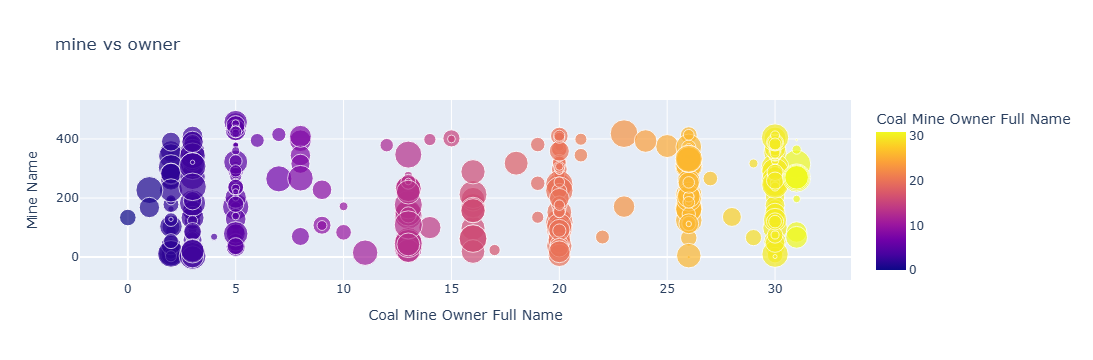

In [84]:
fig6=px.scatter(data,x="Coal Mine Owner Full Name", y="Mine Name",color="Coal Mine Owner Full Name",size="Coal/ Lignite Production (MT) (2019-2020)",title="mine vs owner")
fig6

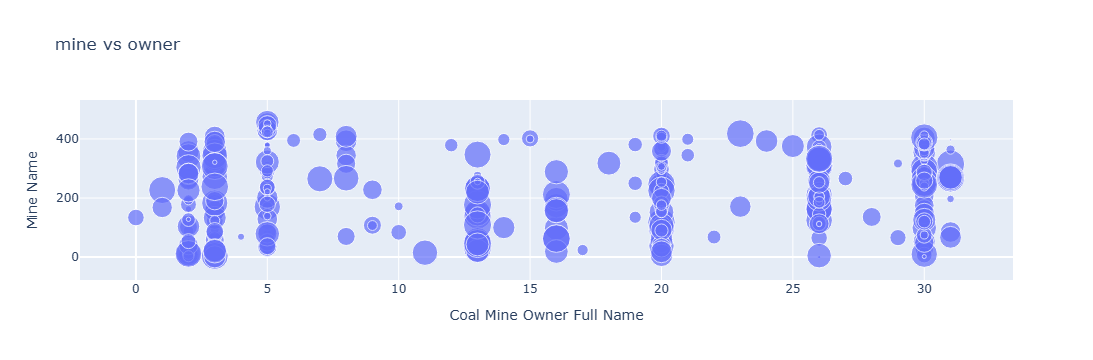

In [85]:
fig6=px.scatter(data,x="Coal Mine Owner Full Name", y="Mine Name",size="Coal/ Lignite Production (MT) (2019-2020)",title="mine vs owner")
fig6

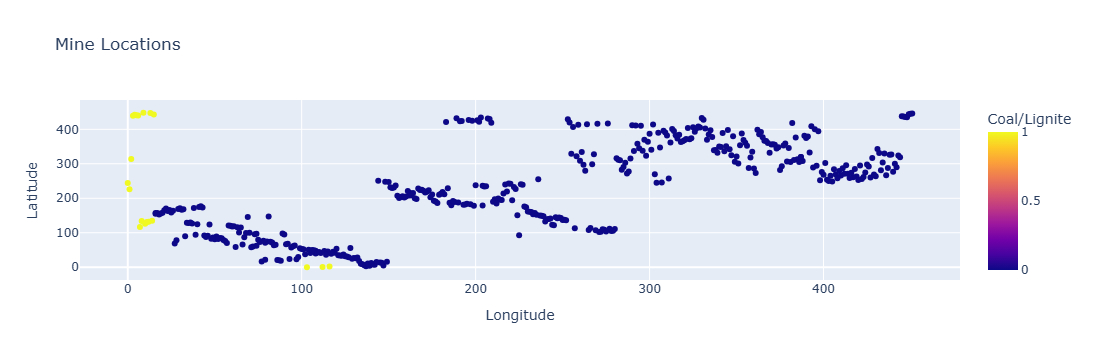

In [86]:
data3=px.scatter(data,x="Longitude ",y="Latitude ",color="Coal/Lignite", title="Mine Locations")
data3

In [87]:
X=data.drop(["Coal/Lignite"],axis=1)
X

,SL No.,State/UT Name,District Name,Mine Name,Coal/ Lignite Production (MT) (2019-2020),Coal Mine Owner Name,Coal Mine Owner Full Name,Govt Owned/Private,Type of Mine (OC/UG/Mixed),Latitude,Longitude,Source,Accuracy (exact vs approximate)
0,1,11,36,294,6,7,5,0,2,294,396,256,111
1,2,11,36,170,215,7,5,0,2,290,442,94,111
2,3,11,36,249,13,7,5,0,2,260,427,242,17
3,4,11,36,449,25,7,5,0,2,262,423,273,44
4,5,11,36,450,19,7,5,0,2,263,419,273,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,455,9,37,111,53,27,26,2,2,17,77,80,111
455,456,9,37,114,64,27,26,2,2,22,79,25,111
456,457,9,37,115,8,27,26,2,2,24,93,25,111
457,458,9,37,113,121,27,26,2,2,21,86,79,111


In [88]:
Y=data['Coal/Lignite']
Y

0      0
1      0
2      0
3      0
4      0
      ..
454    0
455    0
456    0
457    0
458    0
Name: Coal/Lignite, Length: 459, dtype: int64

In [89]:


from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


In [90]:
X

,SL No.,State/UT Name,District Name,Mine Name,Coal/ Lignite Production (MT) (2019-2020),Coal Mine Owner Name,Coal Mine Owner Full Name,Govt Owned/Private,Type of Mine (OC/UG/Mixed),Latitude,Longitude,Source,Accuracy (exact vs approximate)
0,1,11,36,294,6,7,5,0,2,294,396,256,111
1,2,11,36,170,215,7,5,0,2,290,442,94,111
2,3,11,36,249,13,7,5,0,2,260,427,242,17
3,4,11,36,449,25,7,5,0,2,262,423,273,44
4,5,11,36,450,19,7,5,0,2,263,419,273,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,455,9,37,111,53,27,26,2,2,17,77,80,111
455,456,9,37,114,64,27,26,2,2,22,79,25,111
456,457,9,37,115,8,27,26,2,2,24,93,25,111
457,458,9,37,113,121,27,26,2,2,21,86,79,111


In [91]:
Y

0      0
1      0
2      0
3      0
4      0
      ..
454    0
455    0
456    0
457    0
458    0
Name: Coal/Lignite, Length: 459, dtype: int64

In [92]:
x_train.shape


(367, 13)

In [93]:
y_train.shape

(367,)

In [94]:
#defining global variables to store accuracy and other metrics
precision = []
recall = []
fscore = []
accuracy = []
labels = ['Coal', 'Lignite']

In [99]:

def calculateMetrics(algorithm, predict, testY):
    testY = testY.astype('int')
    predict = predict.astype('int')
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+' Accuracy: '+str(a))
    print(algorithm+' Precision : '+str(p))
    print(algorithm+' Recall: '+str(r))
    print(algorithm+' FSCORE: '+str(f))
    report=classification_report(predict, testY,target_names=labels)
    print('\n',algorithm+" classification report\n",report)
    conf_matrix = confusion_matrix(testY, predict)
    plt.figure(figsize =(10, 5))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels,annot = True, cmap="Blues" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix")
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.show()

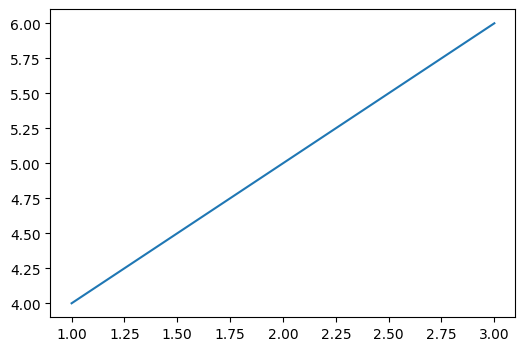

In [100]:
plt.figure(figsize=(6,4))
plt.plot([1,2,3],[4,5,6])
plt.show()

Logistic Regression Accuracy: 100.0
Logistic Regression Precision : 100.0
Logistic Regression Recall: 100.0
Logistic Regression FSCORE: 100.0

 Logistic Regression classification report
               precision    recall  f1-score   support

        Coal       1.00      1.00      1.00        88
     Lignite       1.00      1.00      1.00         4

    accuracy                           1.00        92
   macro avg       1.00      1.00      1.00        92
weighted avg       1.00      1.00      1.00        92



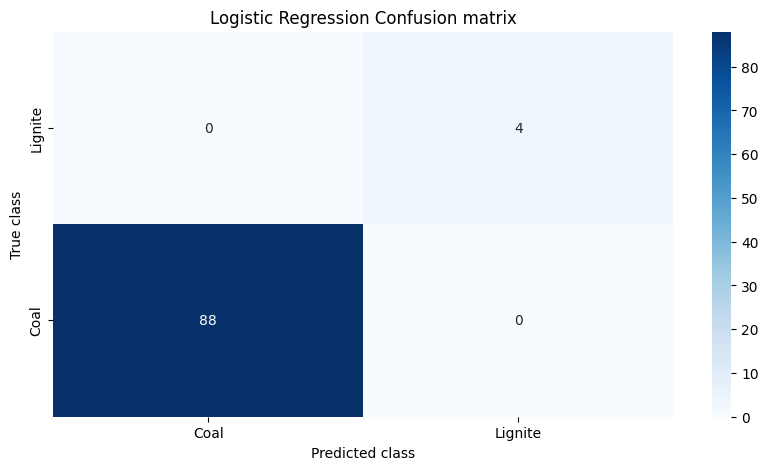

In [101]:
model = 'logistic_regression.pkl'
if os.path.exists(model):
    logistic_regression=joblib.load(model)
    predict=logistic_regression.predict(x_test)
    calculateMetrics("Logistic Regression", predict, y_test)
else:
    logistic_regression=LogisticRegression()
    logistic_regression.fit(x_train,y_train)
    predict=logistic_regression.predict(x_test)
    joblib.dump(logistic_regression,model)
    print("logistic_regression trained and weights saved")
    calculateMetrics("Logistic Regression", predict, y_test)


KNN classifier_model trained and model weights saved.
KNeighborsClassifier Accuracy: 95.65217391304348
KNeighborsClassifier Precision : 47.82608695652174
KNeighborsClassifier Recall: 50.0
KNeighborsClassifier FSCORE: 48.888888888888886

 KNeighborsClassifier classification report
               precision    recall  f1-score   support

        Coal       1.00      0.96      0.98        92
     Lignite       0.00      0.00      0.00         0

    accuracy                           0.96        92
   macro avg       0.50      0.48      0.49        92
weighted avg       1.00      0.96      0.98        92



C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classific

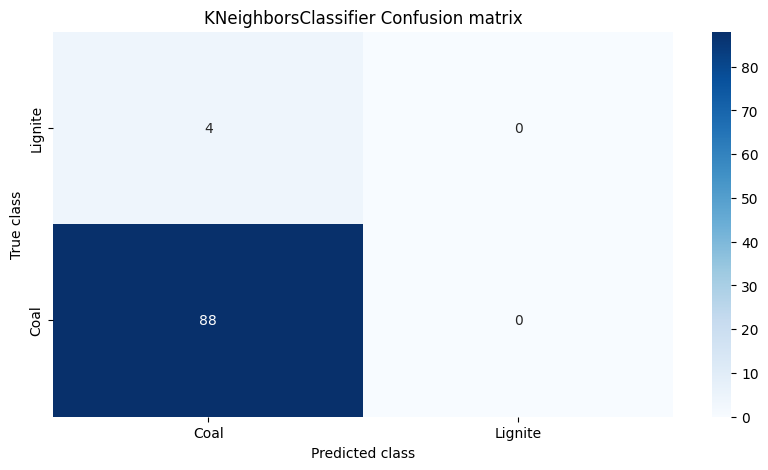

In [103]:
if os.path.exists('KNN_classifier.pkl'):
    classifier= joblib.load('KNN_weights.pkl')
    predict = classifier.predict(x_test)
    calculateMetrics("KNN Classifier", predict, y_test)
else:
    classifier = KNeighborsClassifier(n_neighbors=20)
    classifier.fit(x_train, y_train)
    predict=classifier.predict(x_test)
    joblib.dump(classifier, 'KNN_weights.pkl')
    print("KNN classifier_model trained and model weights saved.")
    calculateMetrics("KNeighborsClassifier", predict, y_test)